In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)
print("라이브러리 준비 완료 ✅")

라이브러리 준비 완료 ✅


In [2]:
# 데이터 불러오기: Ames Housing (1460행 × 81열)
URL = "https://raw.githubusercontent.com/hjhuney/Data/master/AmesHousing/train.csv"
df = pd.read_csv(URL)

print("데이터 크기 (행, 열):", df.shape)
df.head()

데이터 크기 (행, 열): (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# ① 전체 형태 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# 수치형 변수들의 요약 통계
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
# MSSubClass(주택 유형 코드)는 숫자로 저장돼 있다. 직접 확인해보자.

# TODO: dtype, 평균, 고유값을 출력하라
print("MSSubClass dtype :", df['MSSubClass'].dtype)           # 저장 타입
print("MSSubClass 평균  :", round(df['MSSubClass'].mean(), 2))  # 평균 계산
print("MSSubClass 고유값:", sorted(df['MSSubClass'].unique()))    # 고유값 목록
# 출력 결과를 보고 이 변수의 평균값이 의미 있는 숫자인지 생각해보자

MSSubClass dtype : int64
MSSubClass 평균  : 56.9
MSSubClass 고유값: [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]


A1. MSSubClass는 명목척도이다. 따라서 숫자가 크기나 순서가 아니라 단순 카테고리 레이블이기 때문에 평균은 무의미한 계산이다. 숫자가 크다고 크기가 크다고 오해하지 않도록 One-Hot 인코딩을 적용한다.

A2. ExterQual은 순서가 있기 때문에 Ordinal 인코딩으로 처리한다. 각각을 숫자 크기로 순서 정보를 표현하는게 필요하다. Neighborhood는 순서가 없기 때문에 One-Hot 인코딩을 적용한다. 동네 간 크기 관계가 없기 때문에 만약에 숫자를 할당한다면 잘못된 순서 정보가 생기기 때문이다.

In [26]:
!apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 캐시 재빌드
fm.fontManager.__init__()

# 나눔고딕 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


평균  : 180,921
중앙값: 163,000
왜도  : 1.88
첨도  : 6.54


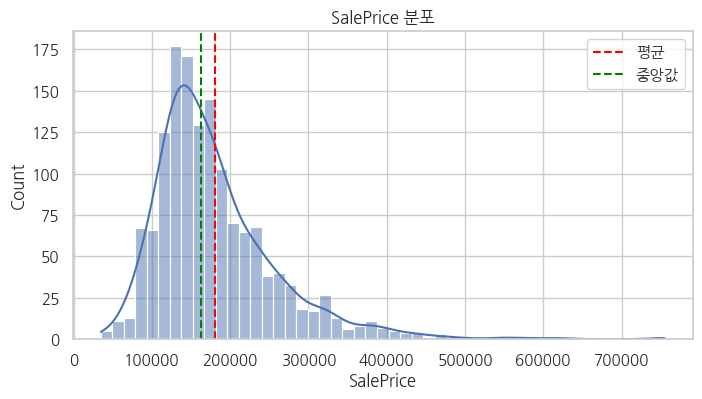

In [27]:
# ① SalePrice 분포 진단
sp = df['SalePrice']

# TODO: 왜도(skewness)와 첨도(kurtosis)를 구하라  (힌트: 시리즈의 .skew() , .kurt())
skew_ = df['SalePrice'].skew()
kurt_ = df['SalePrice'].kurt()

print(f"평균  : {sp.mean():,.0f}")
print(f"중앙값: {sp.median():,.0f}")
print(f"왜도  : {skew_:.2f}")
print(f"첨도  : {kurt_:.2f}")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.figure(figsize=(8,4))
sns.histplot(sp, kde=True)
plt.axvline(sp.mean(),   color='red',   ls='--', label='평균')
plt.axvline(sp.median(), color='green', ls='--', label='중앙값')
plt.title('SalePrice 분포'); plt.legend(); plt.show()

In [12]:
# LotArea(부지 면적)의 평균 vs 중앙값 비교
print(f"LotArea 평균  : {df['LotArea'].mean():,.0f}")
print(f"LotArea 중앙값: {df['LotArea'].median():,.0f}")
print(f"LotArea 최댓값: {df['LotArea'].max():,.0f}  <- 극단값 확인")

LotArea 평균  : 10,517
LotArea 중앙값: 9,478
LotArea 최댓값: 215,245  <- 극단값 확인


A1. 오른쪽 꼬리가 길기 때문에 우왜. 선형 모델은 정규분포를 가정하기 때문에 로그 변환이 필요하다. 변환 후에 왜도는 양수에서 0에 가까운 값으로 감소하게 된다.



A2. 중앙값이 더 적절한 대표값이다. LotArea를 보면 극단적 이상치가 존재하는데 평균은 이상치에 영향을 많이 받기 때문에 중앙값이 더 적절하다.

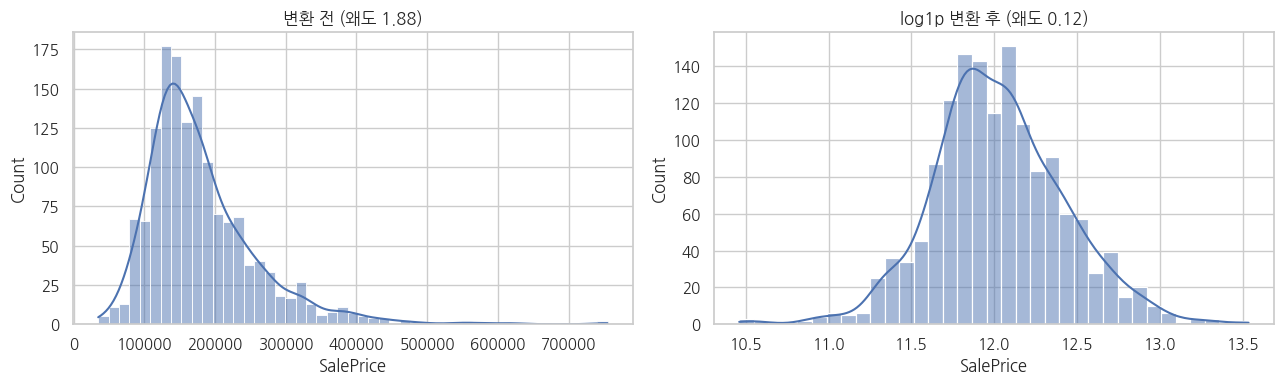

변환 후 왜도가 0에 가까워졌는가? 0.121


In [32]:
# ③ 로그 변환을 직접 적용해 예측이 맞았는지 확인
sp_log = np.log1p(sp)   # log1p = log(1+x), 0이 있어도 안전

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(sp,     kde=True, ax=ax[0]); ax[0].set_title(f'변환 전 (왜도 {sp.skew():.2f})')
sns.histplot(sp_log, kde=True, ax=ax[1]); ax[1].set_title(f'log1p 변환 후 (왜도 {sp_log.skew():.2f})')
plt.tight_layout(); plt.show()
print("변환 후 왜도가 0에 가까워졌는가?", round(sp_log.skew(), 3))

In [28]:
# ① 결측 비율(%) 내림차순
miss = (df.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0].round(1)
print("결측이 있는 컬럼 수:", len(miss))
miss.head(20)

결측이 있는 컬럼 수: 19


,0
PoolQC,99.5
MiscFeature,96.3
Alley,93.8
Fence,80.8
MasVnrType,59.7
FireplaceQu,47.3
LotFrontage,17.7
GarageQual,5.5
GarageFinish,5.5
GarageType,5.5


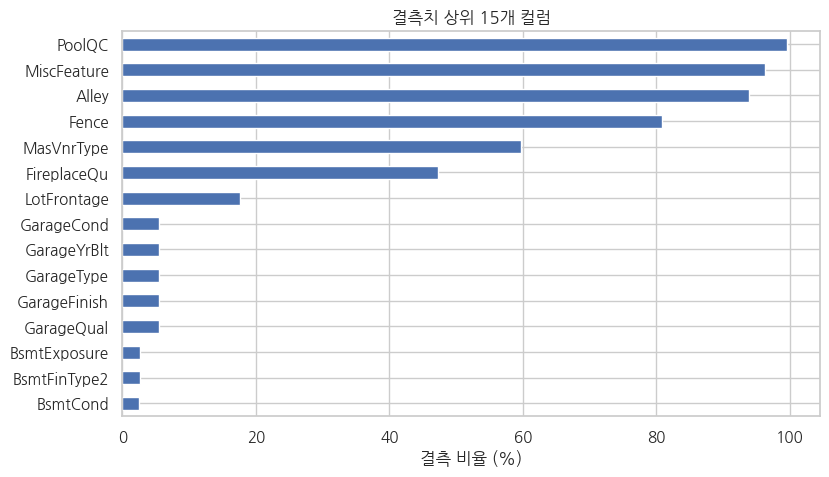

In [29]:
# 결측 비율 상위 시각화
plt.figure(figsize=(9,5))
miss.head(15).sort_values().plot(kind='barh')
plt.xlabel('결측 비율 (%)'); plt.title('결측치 상위 15개 컬럼'); plt.show()

In [31]:
# ② 세 변수의 맥락을 조사해보자
# (a) FireplaceQu(벽난로 품질)가 결측인 집의 Fireplaces(벽난로 개수)는?
print("[FireplaceQu 결측 행의 벽난로 개수]")
print(df.loc[df['FireplaceQu'].isnull(), 'Fireplaces'].value_counts(), "\n")

# (b) MasVnrArea(조적 베니어 면적)의 값 분포 — 0이 얼마나 몰려있나?
# 힌트: 0인지 아닌지를 True/False(=1/0)로 변환 → 합산하면 0의 개수, 평균내면 0의 비율
print("[MasVnrArea] 결측 개수:", df['MasVnrArea'].isnull().sum(),
      "| 값이 0인 비율: %.1f%%" % ((df['MasVnrArea'] == 0).mean() * 100))

# (c) LotFrontage 결측을 전체 중앙값 하나로 채우면 동네마다 도로 폭이 다른데도
# 모든 집에 같은 값이 들어간다. 동네별로 중앙값이 실제로 다른지 확인해보자. >> 도구 : groupby
# TODO: 동네(Neighborhood)를 기준으로 묶어 LotFrontage의 중앙값을 구하라
print("[동네별 LotFrontage 중앙값 (일부)]")
print(df.groupby('Neighborhood')['LotFrontage'].median().dropna().head(6))

[FireplaceQu 결측 행의 벽난로 개수]
Fireplaces
0    690
Name: count, dtype: int64 

[MasVnrArea] 결측 개수: 8 | 값이 0인 비율: 59.0%
[동네별 LotFrontage 중앙값 (일부)]
Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Name: LotFrontage, dtype: float64


A1. 여기서 벽난로 개수가 0이라는 건 벽난로 없음이라는 정보인데 열을 삭제하면 정보 자체가 사라진다. 벽난로 유무를 학습할 수 없기 때문에 결측을 None 문자열로 채워서 하나의 범주로 만든다.
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')
그런 다음 총 6개 범주로 one-hot 인코딩이나 ordinal 인코딩으로 할 수 있다.

A2. 0이 59%인데 전체 평균을 쓰면 평균이 0보다 훨씬 크게 왜곡이 된다. 베니어가 없는 집(MasVnrArea == 0)의 패턴을 보고, 결측도 없음으로 추정하고 0으로 채운다.

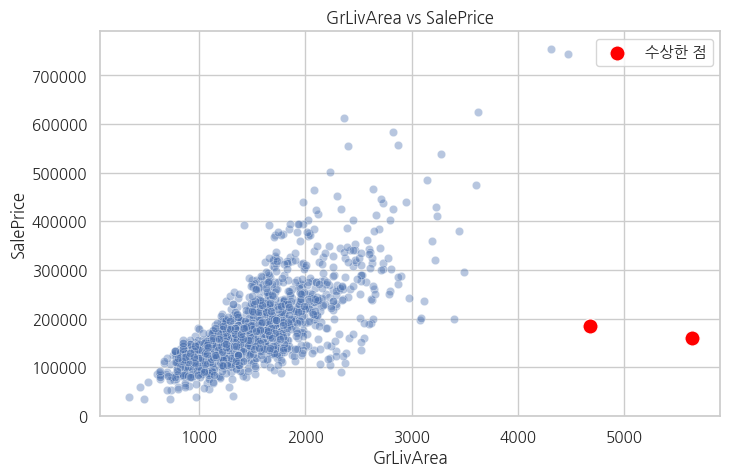

수상한 점 개수: 2
      GrLivArea  SalePrice  OverallQual SaleCondition
523        4676     184750           10       Partial
1298       5642     160000           10       Partial


In [33]:
# ① 산점도로 이상 패턴 찾기
plt.figure(figsize=(8,5))
# TODO: 두 변수의 관계를 산점도로 그려라
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.4)

# 면적은 아주 큰데(>4000) 가격은 낮은(<200000) 수상한 점을 빨간색으로
weird = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)]
# TODO: 위에서 걸러낸 이상점을 빨간색으로 덧그려라
sns.scatterplot(data=weird, x='GrLivArea', y='SalePrice', color='red', s=120, label='수상한 점')
plt.title('GrLivArea vs SalePrice'); plt.legend(); plt.show()

print(f"수상한 점 개수: {len(weird)}")
print(weird[['GrLivArea','SalePrice','OverallQual','SaleCondition']])

In [34]:
# ③ 여러 면적 변수를 더해 Total_Area 파생 변수 생성
df['Total_Area'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

# 새 변수와 기존 변수들의 상관을 확인
print(df[['Total_Area','1stFlrSF','2ndFlrSF','TotalBsmtSF','SalePrice']].corr()['SalePrice'].round(3))

Total_Area     0.782
1stFlrSF       0.606
2ndFlrSF       0.319
TotalBsmtSF    0.614
SalePrice      1.000
Name: SalePrice, dtype: float64


In [ ]:
미완공 상태 거래라면 일반적인 시장 거래가 아닌 특수 케이스다. 따라서 모델이 학습하면 잘못된 패턴을 학습하게 된다. 트리 모델도 이상치를 무시하진 완전히 무시하는 것이 아니끼 때문에 예측 성능에 영향을 가게 된다. 따라서 제거하는 것이 더 낫고, 2건이라 제거해도 정보 손실이 거의 없는 편이다.

원본 3개는 삭제하고 파생변수 Total_Area를 동시에 모델에 넣으면 다중공산성 문제가 생긴다. Total_Area는 세 변수의 합이기 때문에 상관관계가 1에 가깝고 선형 모델은 각 변수의 계수를 안정적으로 추정하지 못하게 된다. 따라서 원본 3개는 제거하고 Total_Area만 유지하는 것이 좋다. 세 변수의 정보가 충분히 표현되기 때문에 정보 손실도 거의 없고 안정적으로 학습할 수 있다.

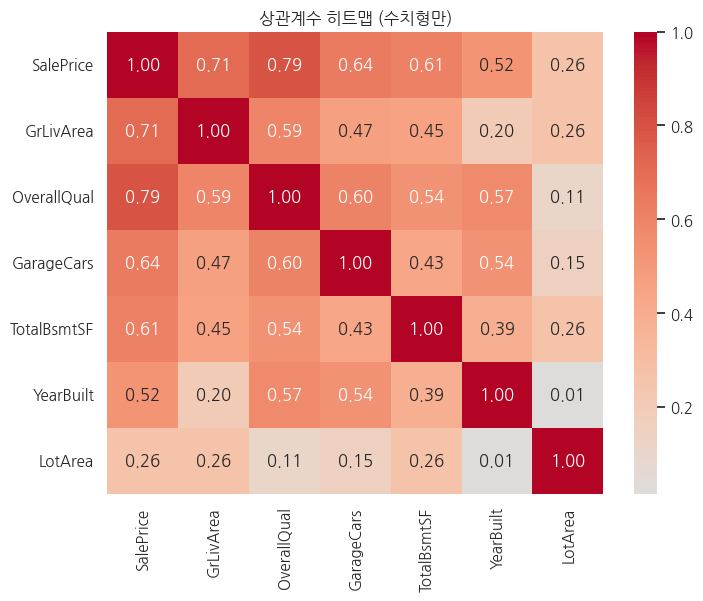

In [35]:
# ① 수치형 상관 히트맵
key = ['SalePrice','GrLivArea','OverallQual','GarageCars','TotalBsmtSF','YearBuilt','LotArea']
plt.figure(figsize=(8,6))
# TODO: 상관계수 행렬을 구하고 히트맵으로 그려라
sns.heatmap(df[key].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('상관계수 히트맵 (수치형만)'); plt.show()

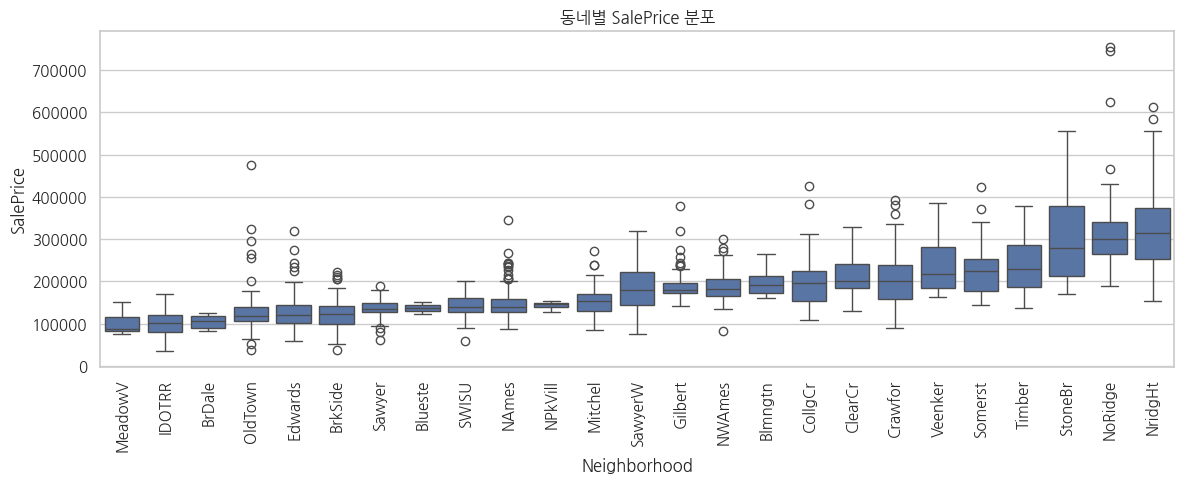

가장 싼 동네 중앙값 88,000 vs 가장 비싼 동네 315,000  (3.6배)


In [36]:
# 히트맵엔 없는 범주형 Neighborhood(동네)의 영향력을 Boxplot으로
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(12,5))
# TODO: 동네별 SalePrice 분포를 박스플롯으로 그려라
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order)
plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()

nb = df.groupby('Neighborhood')['SalePrice'].median()
print(f"가장 싼 동네 중앙값 {nb.min():,.0f} vs 가장 비싼 동네 {nb.max():,.0f}  ({nb.max()/nb.min():.1f}배)")

A1. 히트맵의 맹점은 범주형 변수를 포함하지 못한다는 것이다. df.corr()는 수치형만 포함되고 상관계수는 수치형 변수 간에만 계산되기 때문에 Neighborhood 같은 범주형 변수는 히트맵에 포함되지 않는다. 박스플롯을 보면 가장 싼 동네와 가장 비싼 동네 차이가 3.6배 난다. 동네라는 범주형 변수가 SalePrice에 강한 영향을 미치는데도 히트맵은 이런 사실을 놓치게 된다.

A2. 취등록세는 판매가에 비례해서 매겨진다고 했으므로 판매 후에 매겨지는 값이다. 즉 팔기 전에는 알 수 없는 정보인데 피처로 넣으면 모델이 정답을 학습하게 된다. 실제 예측 환경에는 이 값이 없기 때문에 훈련 때랑 달라지게 된다. 이것이 Target Leakage, 예측 시점에 알 수 없는 미래 정보가 훈련 데이터에 섞여 모델을 오염시키는 것이다.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 간단히 수치형 변수 몇 개만 사용
feats = ['GrLivArea','OverallQual','TotalBsmtSF','GarageCars','LotFrontage']
X = df[feats].copy()
y = np.log1p(df['SalePrice'])

# 1) 가장 먼저 Train/Test 분할  (random_state는 본인 학번 뒤 4자리로!)
# TODO: 아래 ______ 에 본인 학번 앞 4자리 (예: 2021학번이면 2021)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2022)

# 2) 결측 대체: Train 에서 fit, Test 에는 transform 만
imp = SimpleImputer(strategy='median')
X_train_imp = imp.fit_transform(X_train)          # fit_transform: Train 통계를 '학습'하며 변환
# TODO: Test 는 새로 fit 하지 말고, Train 이 학습한 값으로 transform 만 하라
X_test_imp  = imp.transform(X_test)

# 3) 스케일링도 동일 원칙 (Train 에서만 fit)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train_imp)
# TODO: Test 스케일링 (transform 만)
X_test_sc  = sc.transform(X_test_imp)

print("완료 — Train:", X_train_sc.shape, "/ Test:", X_test_sc.shape)
print("Train 중앙값으로 채운 LotFrontage 대체값:", round(imp.statistics_[feats.index('LotFrontage')], 1))

완료 — Train: (1168, 5) / Test: (292, 5)
Train 중앙값으로 채운 LotFrontage 대체값: 70.0


A1. Test Data는 모델이 아직 보지 못한 데이터지만 실제 만나게 될 데이터를 흉내낸 것이다. 여기에 fit하게 되면 Test의 평균이나 중앙값과 같은 통계 정보가 전처리 과정에 포함되게 되므로 학습에 영향을 준다. Data Leakage가 되며, 훈련 때 성능이 좋아보이지만 실제 데이터가 들어오면 성능이 떨어지게 된다.

A2. 전처리를 먼저 하고 분할하면 전체 데이터의 통계로 결측 채우고 스케일링하게 된다. Test 정보가 Train 전처리에 들어가서 같은 문제가 생긴다. 따라서 분할하고 전처리하는 순서를 지켜야 하고, 전처리는 항상 Train에서만 fit하고 Test에서는 transform만 적용한다.

📌 [필수] 생성형 AI 활용

- Claude 사용하여 글씨체 깨지지 않게 코드 추가 (Part 3)

!apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 캐시 재빌드
fm.fontManager.__init__()

# 나눔고딕 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

- Part3의 Q2 풀이 시 더 안전한 대안이 뭐가 되는지 질문하였다.




# 🪞 회고
- 가장 어려웠던 부분
Part 3의 Q2가 어려웠다. 적절한 대안을 생각해내는 것이 힘들었다.
- 강의 땐 이해했다고 생각했지만 직접 실습해보니 변수 적용할 때 코드를 기계적으로 작성하는 것이 아니라 데이터의 맥락을 읽고 판단해야 한다는 것을 느꼈다.